# Problem Background: The Great Migration

**Year: 3050**

The world as we knew it has changed drastically. After decades of conflict, disease, and a relentless zombie apocalypse, the human race faces extinction. The relentless hordes of the undead have ravaged cities, reduced populations, and devastated the planet's ecosystems.

In a desperate bid for survival, the remaining factions of humanity have united to embark on a monumental journey to a new home: **Earth Junior**, a distant planet believed to be free from the scourge of the undead.

As they prepare for this monumental journey, the survival of the human race hinges on their ability to screen potential passengers at the spaceship station. It is crucial that no zombies are allowed to enter the spacecraft, as even a single infected individual could jeopardize the entire mission and the future of humanity.

In this dire situation, you find yourself as the last surviving machine learning engineer, tasked with developing a screening model to predict the zombie-ness of a person. A high human-zombie score would mean the person is likely to be a zombie. The fate of the human race depends on your expertise in machine learning, and you must create a reliable system to ensure the success of this migration to 'Earth Junior'.


# Task 1 -- Linear Regression  

### Introduction

In this assignment, you will be implementing Linear Regression and Logistic Regression models for the provided dataset from scratch, and will be familiarizing yourself with the corresponding scikit-learn APIs. A description of the problem statement is given at the start of each part.

After this notebook you should be able to:

- Set up simple regression tasks.

- Understand the working of Linear Regression models and simple data preprocessing.

- Implement Linear Regression models using simple `numpy`.

Have fun!



# Human-Zombie Dataset

This dataset simulates human and zombie characteristics based on various lifestyle and physical traits. The dataset contains 1,000 entries, each with features that correlate with a continuous "Human-Zombie Score" ranging from 0 (complete human) to 100 (complete zombie).

This generation of human race has smart-chips embedded in their bloodstream that can keep track of and record all these features.

## Features

- **Height (cm):** The height of the individual measured in centimeters, it decreases with zombie score because zombies are known to shrink in height.

- **Weight (kg):** The weight of the individual measured in kilograms. Zombies tend to have a lower weight because of loss of muscle mass, tissue, organs (and soul??).

- **Screen Time (hrs):** The average number of hours spent in front of screens daily. This feature increases with the human-zombie score, reflecting a more sedentary lifestyle.

- **Junk Food (days/week):** The average number of days per week the individual consumes junk food. This feature also increases with the human-zombie score, indicating poorer dietary habits.

- **Physical Activity (hrs/week):** The total hours spent on physical activities per week. This feature decreases as the human-zombie score increases, suggesting a decline in physical activity.

- **Task Completion (scale):** Scale from 0 to 10 representing how often tasks are completed on time (0 = always on time, 10 = never on time). This score decreases with a higher human-zombie score, indicating declining productivity.

- **Human-Zombie Score:** A continuous score from 0 to 100 representing the degree of "zombie-ness" of the individual, where 0 is fully human and 100 is completely zombie-like.

## Usage

This dataset can be used for various analyses, including regression modeling to predict the human-zombie score based on lifestyle and physical traits.


## Multivariate Linear Regression

In this part, you will implement multivariate linear regression (from scratch) to predict the the human-zombie score during screening before the person can be allowed to enter the spaceship.

To do this, you have the human-zombie-datset.csv containing 1000 examples of the features described above and their scores.

Each one of these input features is stored using a different scale. The features include ranges 0-10, 17-100 and some between 130-200.  This is often the case with real-world data, and understanding how to explore and clean such data is an important skill to develop.

A common way to normalize features that use different scales and ranges is:

- Subtract the mean value of each feature from the dataset.

- After subtracting the mean, additionally scale (divide) the feature values by their respective standard deviations.

Note: We only use examples of the train set to estimate the mean and standard deviation.

You have to follow exactly the same steps as above i.e. implement hypothesis, cost function and gradient descent for multivariate linear regression to learn parameters $\theta$ using train set. Finally, report the cost (error) using your learned parameters $\theta$ on test set.








### What is Linear Regression?

Linear regression is a fundamental machine learning algorithm that models the relationship between a dependent variable (target) and one or more independent variables (features) using a linear equation.

**The Linear Regression Equation:**

For multivariate linear regression (multiple features), the hypothesis function is:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n$$

Or in matrix form:
$$h_\theta(x) = \theta^T x$$

Where:
- $h_\theta(x)$ = predicted value (Human-Zombie Score in our case)
- $\theta_0$ = bias term (intercept)
- $\theta_1, \theta_2, ..., \theta_n$ = weights/parameters for each feature
- $x_1, x_2, ..., x_n$ = input features (Height, Weight, Screen Time, etc.)

### What Do We Actually Find in Linear Regression?

Linear regression aims to find the **optimal parameters** $\theta$ that best fit our data. These parameters represent:

1. **$\theta_0$ (Bias)**: The baseline Human-Zombie Score when all features are zero
2. **$\theta_1$ (Height coefficient)**: How much the score changes per cm of height
3. **$\theta_2$ (Weight coefficient)**: How much the score changes per kg of weight
4. **And so on for each feature...**

The goal is to find the $\theta$ values that minimize the difference between our predictions and actual Human-Zombie Scores!

---

## Cost Functions: Measuring Our Mistakes

A cost function measures how wrong our predictions are. Different cost functions have different properties and use cases.

### 1. Mean Squared Error (MSE) - Most Common
$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

**Properties:**
- Penalizes large errors heavily (squared term)
- Differentiable everywhere (good for gradient descent)
- Sensitive to outliers

### 2. Mean Absolute Error (MAE) - Robust to Outliers
$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} |h_\theta(x^{(i)}) - y^{(i)}|$$

**Properties:**
- Linear penalty for errors
- More robust to outliers than MSE
- Not differentiable at zero (can cause issues in optimization)

### 3. Root Mean Squared Error (RMSE) - Interpretable Scale
$$J(\theta) = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2}$$

**Properties:**
- Same scale as the target variable
- Easy to interpret (error in same units as Human-Zombie Score)
- Still sensitive to outliers like MSE

### When to Use Which Cost Function?

- **MSE**: Default choice, works well when you want to penalize large errors
- **MAE**: When your data has outliers or you want equal penalty for all errors
- **RMSE**: When you want interpretable error metrics in the same scale as your target

---

### Part A: Implementation from Scratch

#### Imports

Start off with importing in the required libraries. Note that you are **only** allowed to use `sklearn`'s train_test_split in this part and no other function from `sklearn`.

In [64]:
import numpy as np
import pandas as pd

#### Preparing Data

Load in your dataset and perform train-test split. Apply preprocessing steps to cater to missing values, categorical variables etc. if necessary.

In [65]:
# load dataset and print first few rows

import pandas as pd

df = pd.read_csv("human_zombie_dataset_v5.csv")
df.head()



,Height (cm),Weight (kg),Screen Time (hrs),Junk Food (days/week),Physical Activity (hrs/week),Task Completion (scale),Human-Zombie Score
0,157,41,8.455099,5.622736,4.474819,6.166119,54.881350
1,151,40,8.581430,5.922744,3.749707,1.084877,71.518937
2,166,45,5.018847,5.746557,4.596662,2.030814,60.276338
3,160,75,6.417010,4.634547,4.546153,3.360430,54.488318
4,153,74,4.417465,4.740153,6.601801,5.758603,42.365480


In [66]:
df.shape   # rows, columns
df.columns # feature names
df.info()  # data types

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Height (cm)                   1000 non-null   int64  
 1   Weight (kg)                   1000 non-null   int64  
 2   Screen Time (hrs)             1000 non-null   float64
 3   Junk Food (days/week)         1000 non-null   float64
 4   Physical Activity (hrs/week)  1000 non-null   float64
 5   Task Completion (scale)       1000 non-null   float64
 6   Human-Zombie Score            1000 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 54.8 KB


In [67]:
# train-test-split and shapes checking

from sklearn.model_selection import train_test_split

# Features and target
X = df.drop("Human-Zombie Score", axis=1).values
y = df["Human-Zombie Score"].values.reshape(-1, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(800, 6) (200, 6)


c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\junai\anaconda3\envs\ai_ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


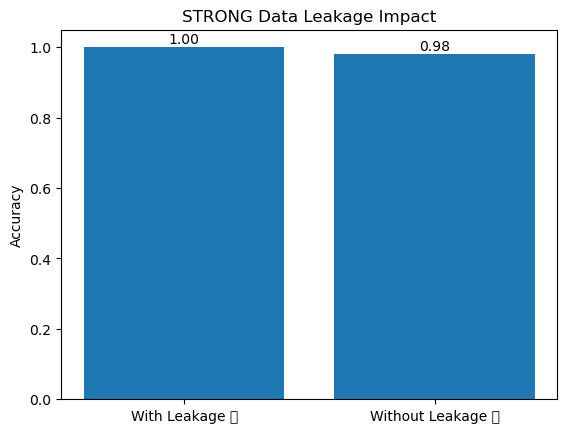

Accuracy with leakage: 1.0000
Accuracy without leakage: 0.9800


In [ ]:
# 🔥 DATA LEAKAGE EXAMPLE (you WILL see difference)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Create dataset
np.random.seed(42)
X = np.random.rand(1000, 5)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

# 2. 🚨 ADD LEAKAGE FEATURE (cheating feature)
X_leak = np.hstack([X, y.reshape(-1, 1)])  # ❌ target leaked into features

# 3. Split
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y, test_size=0.2, random_state=42
)

# 4. Train with leakage
model_l = LogisticRegression()
model_l.fit(X_train_l, y_train_l)
y_pred_l = model_l.predict(X_test_l)
acc_leak = accuracy_score(y_test_l, y_pred_l)

# 5. NORMAL CASE (no leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc_no_leak = accuracy_score(y_test, y_pred)

# 6. Plot
labels = ["With Leakage ❌", "Without Leakage ✅"]
scores = [acc_leak, acc_no_leak]

plt.figure()
plt.bar(labels, scores)
plt.title("STRONG Data Leakage Impact")
plt.ylabel("Accuracy")

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

print(f"Accuracy with leakage: {acc_leak:.4f}")
print(f"Accuracy without leakage: {acc_no_leak:.4f}")

#### Normalizing Data  

For models like Linear/Logistic Regression, and even for Neural Networks, Standardization/Normalization is a non-negotiable step in the preprocessing stage. You would find your model **broken** if you do not normalize your data.

One nice way to implement this is to create a class, `StandardScaler` that can be used to store the mean and standard deviation of each feature of the training set. The `StandardScaler` class also has two functions, `fit` and `transform`.

- The `fit` function is used to calculate the mean and standard deviation of each feature of the training set.

- The `transform` function is used to transform all the features using the corresponding mean and standard deviation, i.e. subtracting the mean and dividing by the standard deviation.

A very subtle and important point to note here is that the mean and standard deviation should be calculated only on the training set, and then applied to the test set. This is because in real-world scenarios, we do not have access to the test set, and hence we cannot calculate the mean and standard deviation of the test set.

In [69]:
from sklearn.preprocessing import StandardScaler


# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

# To see the learned parameters
print("Mean:", scaler.mean_)
print("Std:", scaler.scale_)

print("Scale:",X_train_scaled[:2])

Mean: [0.49470648 0.49482215 0.49399943 0.49498419 0.49424898]
Std: [0.29586987 0.30296661 0.28093211 0.28523347 0.28674371]
Scale: [[-1.5473679   0.37872881  0.03089569 -1.55488568 -0.75189973]
 [-0.70063534 -0.41930746 -1.55164707 -1.34441438  0.07537366]]


## VECTORISATION

In [ ]:
# ## LOOP vs VECTORISED SPEED COMPARISON
import numpy as np
import time

# -----------------------------
# Data
# -----------------------------
X = np.random.rand(10000, 10)
theta = np.random.rand(10, 1)

# =========================================================
# 🔴 LOOP VERSION (AVERAGED)
# =========================================================
start = time.time()

for _ in range(5):  # repeat for stable timing
    result_loop = []
    for i in range(X.shape[0]):
        sum_val = 0
        for j in range(X.shape[1]):
            sum_val += X[i][j] * theta[j][0]
        result_loop.append(sum_val)

end = time.time()
loop_time = end - start

print("🔴 Loop Time:", loop_time)


# =========================================================
# 🟢 VECTORIZED VERSION (AVERAGED)
# =========================================================
start = time.time()

for _ in range(100):  # more repeats because it's very fast
    result_vector = np.dot(X, theta)

end = time.time()
vector_time = end - start

print("🟢 Vectorized Time:", vector_time)


# =========================================================
# ⚡ COMPARISON
# =========================================================
print("\n⚡ Speed Comparison:")

if vector_time > 0:
    print("Loop / Vectorized =", loop_time / vector_time, "x slower")
else:
    print("Vectorized too fast to measure accurately ⚡")

🔴 Loop Time: 0.700599193572998
🟢 Vectorized Time: 0.002999544143676758

⚡ Speed Comparison:
Loop / Vectorized = 233.56855575868374 x slower


## Gradient Descent: The Mathematical Journey to Minimum

### What is Gradient Descent?

Imagine you're a zombie trying to find the lowest point in a valley (minimum cost) while blindfolded. Gradient descent is like feeling the slope of the ground and taking steps in the steepest downhill direction!

### The Mathematics Behind Gradient Descent

**The Gradient**: The gradient $\nabla J(\theta)$ tells us the direction of steepest increase in our cost function.

For MSE cost function, the gradient with respect to each parameter is:

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

**The Update Rule**: We move in the opposite direction of the gradient:

$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$$

Where:
- $\alpha$ = learning rate (how big steps we take)
- $\frac{\partial J(\theta)}{\partial \theta_j}$ = partial derivative (slope) of cost function

### How We Calculate Gradients Step by Step:

1. **Forward Pass**: Calculate predictions using current $\theta$
2. **Calculate Error**: Find difference between predictions and actual values
3. **Calculate Gradients**: Use the error to compute how much to change each $\theta$
4. **Update Parameters**: Move $\theta$ in the direction that reduces cost
5. **Repeat**: Until convergence or maximum iterations


#### Gradient Descent Implementation




Now that your data is ready, you can start implementing the gradient descent algorithm.

You should be creating a class `LinearRegression`. This means implementing the following methods:

- `__init__`: The constructor of the class. You can initialize any variables, like the learning rate and the number of iterations, here.

- `fit`: This method will be used to train your model. It should take in the training data and labels as parameters, and learn the parameters using gradient descent. Save the loss values after every iteration in a list, and return it (for plotting later).

- `predict`: This method will be used to predict the labels for a given set of test data. It should take in the test data as a parameter, and return the predicted labels.

- `score`: This method will be used to calculate the mean square error for the test data. It should take in the test data and labels as parameters, and return the mean square error. Note that this is a unique case where the loss function and the final reported metric are the same.




1. Implement the `LinearRegression` class with support for different cost functions
2. Add methods for MSE, MAE, and RMSE
3. Compare how different cost functions affect the learning process
4. Visualize the gradient descent path

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


class LinearRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, cost_function='mse'):
        """
        Initialize Linear Regression with different cost function options
        """
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.cost_function = cost_function
        self.cost_history = []
        self.theta = None
        self.X_mean = None
        self.X_std = None

    def _add_bias(self, X): # Adds intercept term (θ₀) to the model, Because model equation
        """Add bias term (column of ones) to feature matrix X"""
        ones = np.ones((X.shape[0], 1))
        return np.hstack((ones, X))

    def _normalize_features(self, X, is_training=False):
        """Normalize features to have zero mean and unit variance"""
        if is_training:
            self.X_mean = np.mean(X, axis=0)
            self.X_std = np.std(X, axis=0)

        return (X - self.X_mean) / (self.X_std + 1e-8)

    def _compute_cost(self, predictions, y):
        """
        Compute cost based on selected cost function
        """
        m = len(y)

        if self.cost_function == 'mse':
            return (1/(2*m)) * np.sum((predictions - y) ** 2)

        elif self.cost_function == 'mae':
            return (1/m) * np.sum(np.abs(predictions - y))

        elif self.cost_function == 'rmse':
            return np.sqrt((1/m) * np.sum((predictions - y) ** 2))

    def _compute_gradients(self, X, predictions, y):
        """
        Compute gradients based on selected cost function
        """
        m = len(y)
        error = predictions - y

        if self.cost_function in ['mse', 'rmse']:
            gradients = (1/m) * np.dot(X.T, error)

        elif self.cost_function == 'mae':
            gradients = (1/m) * np.dot(X.T, np.sign(error))

        return gradients

    def fit(self, X, y, verbose=True):
        """
        Train the model using gradient descent
        """
        X = self._normalize_features(X, is_training=True)
        X = self._add_bias(X)

        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.cost_history = []

        for i in range(self.num_iterations):
            predictions = np.dot(X, self.theta)

            cost = self._compute_cost(predictions, y)
            self.cost_history.append(cost)

            gradients = self._compute_gradients(X, predictions, y)
            self.theta -= self.learning_rate * gradients

            if verbose and i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")

        return self.cost_history

    def predict(self, X):
        """
        Make predictions on new data
        """
        X = self._normalize_features(X, is_training=False)
        X = self._add_bias(X)
        return np.dot(X, self.theta)

    def score(self, X, y):
        """
        Calculate mean squared error on test data
        """
        predictions = self.predict(X)
        return np.mean((predictions - y) ** 2)

    def plot_cost_history(self):
        """Plot the cost history during training"""
        plt.figure()
        plt.plot(self.cost_history)
        plt.xlabel("Iterations")
        plt.ylabel("Cost")
        plt.title("Cost vs Iterations")
        plt.show()

    def plot_gradient_descent_path(self, X, y, theta0_range=(-10, 10), theta1_range=(-10, 10), resolution=50):
        """
        Simplified visualization (works best with single feature)
        """
        # Only take first feature for visualization
        X = X[:, 0].reshape(-1, 1)

        X_norm = self._normalize_features(X, is_training=True)
        X_b = self._add_bias(X_norm)

        theta0_vals = np.linspace(theta0_range[0], theta0_range[1], resolution)
        theta1_vals = np.linspace(theta1_range[0], theta1_range[1], resolution)

        J_vals = np.zeros((resolution, resolution))

        for i in range(resolution):
            for j in range(resolution):
                theta_temp = np.array([[theta0_vals[i]], [theta1_vals[j]]])
                preds = np.dot(X_b, theta_temp)
                J_vals[i, j] = (1/(2*len(y))) * np.sum((preds - y) ** 2)

        plt.figure()
        plt.contour(theta0_vals, theta1_vals, J_vals.T, levels=30)

        # Plot learned theta
        plt.scatter(self.theta[0], self.theta[1], color='red', label='Final Theta')

        plt.xlabel("Theta 0")
        plt.ylabel("Theta 1")
        plt.title("Gradient Descent Path (Simplified)")
        plt.legend()
        plt.show()

### Part B: Regularized Linear Regression Using Scikit-learn

Now, you'll use the [scikit-learn](https://scikit-learn.org/stable/index.html) to implement [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge), [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso), [Elastic Net](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#sklearn.linear_model.ElasticNet) and apply them to the human-zombie dataset.

Try out different values of regularization coefficient (known as `alpha` in `sklearn`) and use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to report loss with each regression.

Finally, plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$ (y-axis) for Ridge and Lasso. Please read [this blog](https://scienceloft.com/technical/understanding-lasso-and-ridge-regression/) to get better understanding of the desired plots.


#### Importing Libraries

You have to use scikit-learn for this task

In [72]:
# Part B: Regularized Linear Regression Using Scikit-learn

# Import required libraries
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression as SkLinear
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [73]:
# Standardization is IMPORTANT for regression models with regularization

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data (NO re-fitting)
X_test_scaled = scaler.transform(X_test)

# Check shapes after scaling
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Scaled Training Shape: (800, 5)
Scaled Testing Shape: (200, 5)


#### Linear Regression (using `sklearn`)

Use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to find loss and print it.

In [74]:
# -------------------------------
# Linear Regression (No Regularization)
# -------------------------------

# Initialize model
lr = SkLinear()

# Train model
lr.fit(X_train_scaled, y_train)

# Predict on test data
pred_lr = lr.predict(X_test_scaled)

# Evaluate using Mean Squared Error
print("Linear Regression MSE:", mean_squared_error(y_test, pred_lr))

Linear Regression MSE: 0.07819563687198246


#### Ridge

Use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to find loss and print it. Also plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$  (y-axis) for Ridge.

In [75]:
# -------------------------------
# Ridge Regression (L2 Regularization)
# -------------------------------

alphas = [0.01, 0.1, 1, 10, 100]

ridge_coefs = []

for a in alphas:
    # Create Ridge model with different alpha values
    ridge = Ridge(alpha=a)

    # Train model
    ridge.fit(X_train_scaled, y_train)

    # Predict
    pred = ridge.predict(X_test_scaled)

    # Calculate error
    mse = mean_squared_error(y_test, pred)

    print(f"Ridge Regression (alpha={a}) MSE: {mse}")

    # Store coefficients for visualization
    ridge_coefs.append(ridge.coef_)

Ridge Regression (alpha=0.01) MSE: 0.07819617580621642
Ridge Regression (alpha=0.1) MSE: 0.07820102755553403
Ridge Regression (alpha=1) MSE: 0.07824967740745015
Ridge Regression (alpha=10) MSE: 0.07874899944028807
Ridge Regression (alpha=100) MSE: 0.08468437360770993


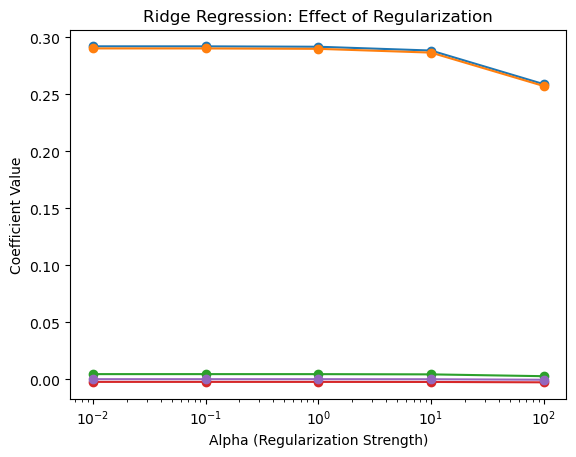

In [76]:
# -------------------------------
# Ridge: Alpha vs Coefficients Plot
# -------------------------------

import matplotlib.pyplot as plt

ridge_coefs = np.array(ridge_coefs)

plt.figure()

# Plot coefficient change for each feature
for i in range(ridge_coefs.shape[1]):
    plt.plot(alphas, ridge_coefs[:, i], marker='o')

plt.xscale('log')  # alpha grows exponentially
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regression: Effect of Regularization")
plt.show()

#### Lasso

Use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to find loss and print it. Also plot the regularization coefficients alpha (x-axis) with learned parameters $\theta$  (y-axis) for Lasso.

In [77]:
# -------------------------------
# Lasso Regression (L1 Regularization)
# -------------------------------

lasso_coefs = []

for a in alphas:
    # Create Lasso model
    lasso = Lasso(alpha=a, max_iter=10000)

    # Train model
    lasso.fit(X_train_scaled, y_train)

    # Predict
    pred = lasso.predict(X_test_scaled)

    # Evaluate
    mse = mean_squared_error(y_test, pred)

    print(f"Lasso Regression (alpha={a}) MSE: {mse}")

    # Store coefficients
    lasso_coefs.append(lasso.coef_)

Lasso Regression (alpha=0.01) MSE: 0.07966304617188738
Lasso Regression (alpha=0.1) MSE: 0.10923966814861093
Lasso Regression (alpha=1) MSE: 0.25205625
Lasso Regression (alpha=10) MSE: 0.25205625
Lasso Regression (alpha=100) MSE: 0.25205625


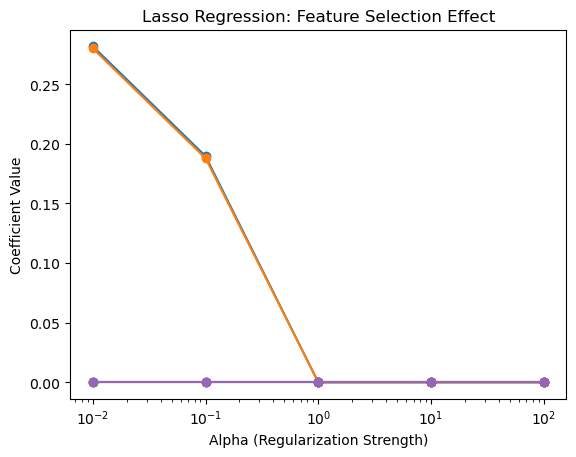

In [78]:
# -------------------------------
# Lasso: Alpha vs Coefficients Plot
# -------------------------------

lasso_coefs = np.array(lasso_coefs)

plt.figure()

# Plot coefficient shrinkage
for i in range(lasso_coefs.shape[1]):
    plt.plot(alphas, lasso_coefs[:, i], marker='o')

plt.xscale('log')
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression: Feature Selection Effect")
plt.show()

#### Elastic Net

Use the [Mean Squared Error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) to find loss and print it.

In [79]:
# -------------------------------
# Elastic Net (L1 + L2 Combination)
# -------------------------------

elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Train model
elastic.fit(X_train_scaled, y_train)

# Predict
pred_en = elastic.predict(X_test_scaled)

# Evaluate model
print("Elastic Net MSE:", mean_squared_error(y_test, pred_en))

Elastic Net MSE: 0.25205625
